# LangChain + Geopack MCP — geocode then search

Teaches the **geocode → list** workflow:

1. `geopack_sdk_geocode_place` → WGS84 bbox
2. `geopack_sdk_list_datasets(bbox=..., data_type=...)`

Same discovery pattern as [`examples/langchain_geopack_geocode_workflow.py`](../examples/langchain_geopack_geocode_workflow.py), shown step-by-step in the notebook.

See also: [`examples/langchain_geopack_agent.py`](../examples/langchain_geopack_agent.py) for the minimal terminal sample.

In [ ]:
%pip install -q python-dotenv nest_asyncio
%pip install -q -e "../.[langchain]"

In [1]:
import sys
from pathlib import Path

import nest_asyncio
from dotenv import load_dotenv

nest_asyncio.apply()

NOTEBOOK_DIR = Path.cwd()
SDK_ROOT = NOTEBOOK_DIR.parent if (NOTEBOOK_DIR / "lib").is_dir() else NOTEBOOK_DIR
sys.path.insert(0, str(SDK_ROOT / "src"))
sys.path.insert(0, str(SDK_ROOT / "notebooks" / "lib"))

load_dotenv(SDK_ROOT / "notebooks" / ".env")
load_dotenv(SDK_ROOT / ".env")

from notebook_langchain import setup_notebook_paths, load_env

SDK_ROOT = setup_notebook_paths()
load_env(SDK_ROOT)

## Step 1 — Environment & MCP tools

In [2]:
import os
from notebook_langchain import notebook_mcp_langchain_tools, create_chat_model, GEOCODE_SYSTEM_PROMPT

assert os.getenv("GEOPACK_API_URL") and os.getenv("OPENAI_API_KEY")

if "mcp_ctx" in globals() and mcp_ctx is not None:
    await mcp_ctx.__aexit__(None, None, None)
mcp_ctx = notebook_mcp_langchain_tools()
tools, mcp_session, transport = await mcp_ctx.__aenter__()
print("Transport:", transport, "| tools:", len(tools))

Transport: inprocess | tools: 16


## Step 2 — Agent with geocode-first system prompt

The LLM is instructed to call **geocode** before **list** when the user mentions a place.

In [3]:
from langchain.agents import create_agent

llm = create_chat_model()
agent = create_agent(llm, tools, system_prompt=GEOCODE_SYSTEM_PROMPT)
print("System prompt requires geocode → list when a place is mentioned.")

langchain-openai detected system proxy configuration and no explicit `http_socket_options` / `http_client` / `http_async_client` / `openai_proxy`; skipping the custom `httpx` transport so httpx's env-proxy auto-detection applies. Pass `http_socket_options=[...]` to opt back into kernel-level TCP keepalive tuning on top of the env proxy.


System prompt requires geocode → list when a place is mentioned.


## Step 3 — Run prompt (Tehran rasters example)

In [4]:
USER_PROMPT = "Find vector datasets in the Tehran province since 2024."
#USER_PROMPT ="مشخصات دیتاست 2421 را نمایش بده"
print("User:", USER_PROMPT)
agent_result = await agent.ainvoke({"messages": USER_PROMPT})
messages = agent_result.get("messages", [])

User: Find vector datasets in the Tehran province since 2024.


HTTP Request: POST https://models.github.ai/inference/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://models.github.ai/inference/chat/completions "HTTP/1.1 200 OK"
HTTP Request: POST https://models.github.ai/inference/chat/completions "HTTP/1.1 200 OK"


## Step 4 — Inspect tool chain (geocode → list)

In [5]:
import json
from langchain_core.messages import ToolMessage
from notebook_langchain import last_assistant_text
from display_datasets import print_tool_trace
print_tool_trace(messages, max_tools=12)

for msg in messages:
    if isinstance(msg, ToolMessage) and "bbox" in (msg.content or ""):
        try:
            geo = json.loads(msg.content)
            if "bbox" in geo:
                print("\nGeocode bbox:", geo.get("bbox"))
                print("Place:", geo.get("display_name"))
        except json.JSONDecodeError:
            pass

print("\n--- Assistant ---\n")
print(last_assistant_text(agent_result))

--- Tool trace ---
  → geopack_sdk_geocode_place({"query": "Tehran province, Iran"})
    ← {"display_name": "\u0627\u0633\u062a\u0627\u0646 \u062a\u0647\u0631\u0627\u0646, \u0627\u06cc\u0631\u0627\u0646", "lat":...
  → geopack_sdk_list_datasets({"bbox": "[50.3327898, 34.8652387, 53.1569031, 36.1016137]", "data_type": "vector", "details_level": "lite", "page_size": 5, "start_date": "2024-01-01"})
    ← {"datasets": [{"id": 1950, "name": "testpoly", "description": null, "dataType": "vector", "subType": null, "keywords": "...

Geocode bbox: [50.3327898, 34.8652387, 53.1569031, 36.1016137]
Place: استان تهران, ایران

--- Assistant ---

Here are vector datasets in Tehran province since 2024:

1. testpoly
   - Shape: MultiPolygon
   - Created: 2025-12-02

2. dd
   - Shape: MultiPolygon
   - Description: Dataset from file: dd.shp
   - Created: 2025-11-12

3. cp2
   - Shape: MultiPolygon
   - Description: Created by workflow persist operation
   - Created: 2025-11-07

4. Town_Limit
   - Shape: 

## Step 5 — HTML table + thumbnails

Datasets from list_datasets tool: 5


Preview,ID,Name,Type,Updated
—,1950,testpoly,vector,2025-12-02T06:20:48.437000Z
,1621,dd,vector,2025-11-12T16:02:21.924000Z
,1581,cp2,vector,2025-11-07T07:11:41.142000Z
,701,Town_Limit,vector,2025-08-11T19:32:05.697000Z
,700,estate,vector,2025-08-11T19:32:05.693000Z

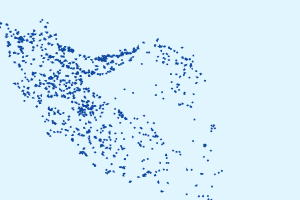
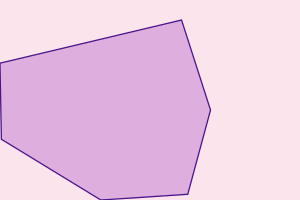
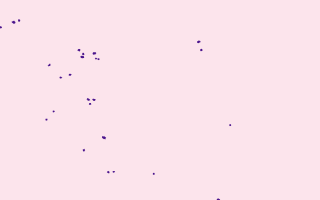
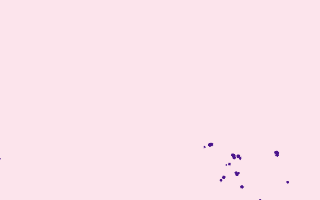

In [6]:
from notebook_langchain import extract_list_datasets_from_messages
from display_datasets import display_datasets_rich

datasets = extract_list_datasets_from_messages(messages)
print(f"Datasets from list_datasets tool: {len(datasets)}")
await display_datasets_rich(datasets, mcp_session, max_rows=8)

In [7]:
await mcp_ctx.__aexit__(None, None, None)

False